In [1]:
# --- Step 1: Setup & Imports ---
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
# include .. in the path
import sys
import os

sys.path.insert(0, "..")

# physical constants
lya_wavelength = 1215.6701
lyb_wavelength = 1025.7223
lyg_wavelength = 972.5368
lyman_limit    = 911.7633
speed_of_light = 299792458

nv_wavelength = 1240.81
oi_wavelength = 1305.53
cii_wavelength = 1335.31
siv_wavelength = 1399.8

# oscillator strengths
lya_oscillator_strength = 0.416400
lyb_oscillator_strength = 0.079120


cmap = cm.get_cmap('viridis')

# change fontsize
matplotlib.rcParams.update({'font.size' : 14})

# matplotlib.use('PDF')

save_figure = lambda filename : plt.savefig("{}.pdf".format(filename), format="pdf", dpi=300)



/var/folders/sn/b7hd1bmd569cjwgmtww4mv440000gn/T/ipykernel_91074/2319518203.py:30: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis')


In [2]:
import torch

## Visualize New Model

In [3]:
import h5py
import numpy as np
import os

class QSOModelLoader:
    def __init__(self, filepath, is_model_epoch=False):
        """
        Load an HDF5 file and store only the specified datasets as attributes.

        Parameters:
        filepath (str): Path to the HDF5 file.
        """
        self.filepath = filepath
        self.is_model_epoch = is_model_epoch
        
        # Keys that should be loaded
        self.keys_to_load = {
            "M", "initial_M", "initial_beta", "initial_log_c_0",
            "initial_log_omega", "initial_tau_0", "log_beta", "log_c_0",
            "log_likelihood", "log_omega", "log_tau_0", "mu", "rest_wavelengths",
            "log_beta_history", "log_c_0_history", "log_tau_0_history", "loss_history",
            "max_noise_variance", "train_ind", "training_release"
        }
        self._load_file()

    def _load_file(self):
        """Load an HDF5 file and assign only the specified datasets as instance attributes."""
        with h5py.File(self.filepath, "r") as f:
            for key in self.keys_to_load:
                if key in f:  # Check if the key exists in the file
                    data = self._load_data(f[key])
                    setattr(self, key, data)

            # Special processing rules
            if "M" in self.keys_to_load and hasattr(self, "M"):
                if not self.is_model_epoch:  # If this is model_epoch_6.h5, transpose M
                    self.M = self.M.T

            # If it's a .mat file, extract [:, 0] for specific keys
            if not self.is_model_epoch:
                for key in ["log_tau_0", "log_beta", "log_c_0", "initial_log_c_0"]:
                    if hasattr(self, key) and self.__dict__[key].ndim > 1:
                        self.__dict__[key] = self.__dict__[key][0, 0]
                for key in ["rest_wavelengths", "mu", "log_omega"]:
                    if hasattr(self, key):
                        self.__dict__[key] = self.__dict__[key][:,0]

        # Compute the correlation matrix
        K = np.dot(self.M, self.M.T)
        self.C = K / np.sqrt(np.outer(np.diag(K), np.diag(K)))

    def _load_data(self, dataset):
        """Automatically handle scalars and arrays in HDF5 datasets."""
        return dataset[()] if dataset.shape == () else dataset[:]

    def keys(self):
        """List all available attributes that were loaded."""
        return [attr for attr in self.keys_to_load if hasattr(self, attr)]

# Example usage:
file1 = "../data/dr12q/processed/learned_qso_model_lyseries_variance_wmu_boss_dr16q_minus_dr12q_gp_851-1421.mat"
file2 = "../data/loa/learnlogs/model_epoch_440.h5"
file3 = "../data/london/learnlogs_london/model_epoch_99.h5"

qso_model = QSOModelLoader(file1)
loa_model = QSOModelLoader(file2, is_model_epoch=True)
london_model = QSOModelLoader(file3, is_model_epoch=True)

# List available attributes
print("Keys in qso_model:", qso_model.keys())
print("Keys in loa_model:", loa_model.keys())
print("Keys in london_model:", london_model.keys())

# Access data as attributes
print("Shape of M from qso_model:", qso_model.M.shape)  # Should be normal
print("Shape of M from loa_model:", loa_model.M.shape)  # Should be transposed
print("Shape of M from london_model:", london_model.M.shape)  # Should be transposed

# Access a scalar
print("log_c_0 (scalar) from qso_model:", np.exp(qso_model.log_c_0))  # Should be [:, 0]
print("log_c_0 (scalar) from loa_model:", np.exp(loa_model.log_c_0))  # Should be a direct scalar
print("log_c_0 (scalar) from london_model:", np.exp(london_model.log_c_0))  # Should


print("log_tau_0 from qso_model:", np.exp(qso_model.log_tau_0))  # Should be [:, 0]
print("log_tau_0 from loa_model:", np.exp(loa_model.log_tau_0))  # Should be a scalar
print("log_tau_0 from london_model:", np.exp(london_model.log_tau_0))  # Should be a scalar

print("log_beta from qso_model:", np.exp(qso_model.log_beta))  # Should be [:, 0]
print("log_beta from loa_model:", np.exp(loa_model.log_beta))  # Should be a scalar
print("log_beta from london_model:", np.exp(london_model.log_beta))  # Should be a scalar

Keys in qso_model: ['mu', 'log_c_0', 'initial_beta', 'max_noise_variance', 'log_likelihood', 'initial_log_omega', 'initial_M', 'initial_log_c_0', 'train_ind', 'log_tau_0', 'initial_tau_0', 'rest_wavelengths', 'log_omega', 'log_beta', 'M', 'training_release']
Keys in loa_model: ['mu', 'log_c_0', 'initial_beta', 'max_noise_variance', 'loss_history', 'initial_log_omega', 'initial_M', 'initial_log_c_0', 'log_beta_history', 'log_tau_0', 'log_tau_0_history', 'rest_wavelengths', 'log_omega', 'log_beta', 'M', 'log_c_0_history']
Keys in london_model: ['mu', 'log_c_0', 'initial_beta', 'max_noise_variance', 'loss_history', 'initial_log_omega', 'initial_M', 'initial_log_c_0', 'log_beta_history', 'log_tau_0', 'log_tau_0_history', 'rest_wavelengths', 'log_omega', 'log_beta', 'M', 'log_c_0_history']
Shape of M from qso_model: (2281, 20)
Shape of M from loa_model: (3798, 30)
Shape of M from london_model: (3798, 30)
log_c_0 (scalar) from qso_model: 0.14598947100436402
log_c_0 (scalar) from loa_model: 0

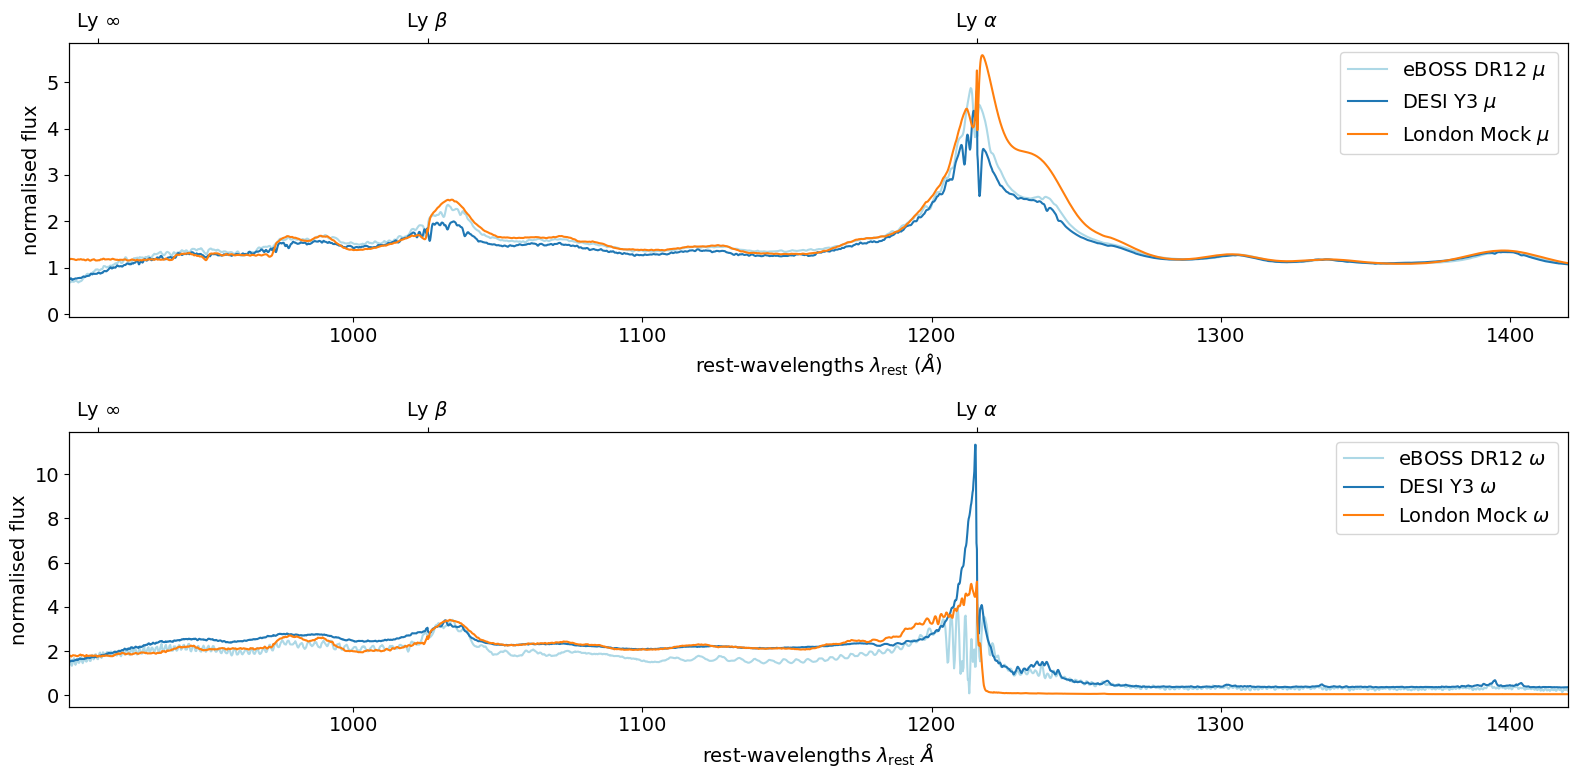

In [4]:
# scaling factor between rest_wavelengths to pixels
min_lambda = lyman_limit - 10
max_lambda = 1420
scale = 1 / ( max_lambda - min_lambda )

# compare different learned mus
fig, ax = plt.subplots(2, 1, figsize=(16, 8))
ax[0].plot(
    qso_model.rest_wavelengths, qso_model.mu, label=r"eBOSS DR12 $\mu$", color="lightblue")
ax[0].plot(
    loa_model.rest_wavelengths, loa_model.mu, label=r"DESI Y3 $\mu$", )
ax[0].plot(
    london_model.rest_wavelengths, london_model.mu, label=r"London Mock $\mu$", )


ax[0].legend()
ax[0].set_xlabel(r"rest-wavelengths $\lambda_{\mathrm{rest}}$ $(\AA)$")
ax[0].set_ylabel(r"normalised flux")
ax[0].set_xlim([min_lambda, max_lambda])

ax02 = ax[0].twiny()
ax02.set_xticks(
    [(lyman_limit - min_lambda) * scale, (lyb_wavelength - min_lambda) * scale, (lya_wavelength - min_lambda) * scale])
ax02.set_xticklabels([r"Ly $\infty$", r"Ly $\beta$", r"Ly $\alpha$"])

# compare different learned omegas
ax[1].plot(
    qso_model.rest_wavelengths, np.exp(qso_model.log_omega), label=r"eBOSS DR12 $\omega$", color="lightblue")
ax[1].plot(
    loa_model.rest_wavelengths, np.exp(loa_model.log_omega ), label=r"DESI Y3 $\omega$", )
ax[1].plot(
    london_model.rest_wavelengths, np.exp(london_model.log_omega), label=r"London Mock $\omega$", )

ax[1].legend()
ax[1].set_xlabel(r"rest-wavelengths $\lambda_{\mathrm{rest}}$ $\AA$")
ax[1].set_ylabel(r"normalised flux")
ax[1].set_xlim([min_lambda, max_lambda])

ax12 = ax[1].twiny()
ax12.set_xticks(
    [(lyman_limit - min_lambda) * scale, (lyb_wavelength - min_lambda) * scale, (lya_wavelength - min_lambda) * scale])
ax12.set_xticklabels([r"Ly $\infty$", r"Ly $\beta$", r"Ly $\alpha$"])

plt.tight_layout()
save_figure("mu_omega_changes")
# plt.clf()


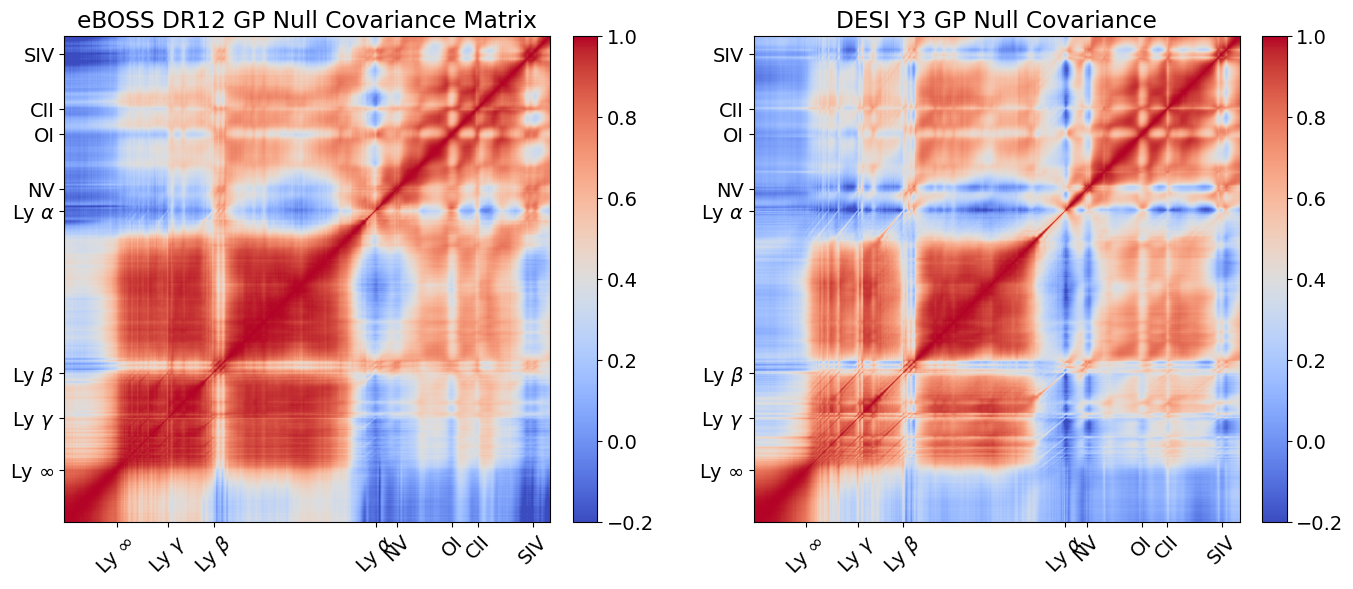

In [5]:
import matplotlib.pyplot as plt
import numpy as np

def plot_covariance_matrices(
    qso_model, loa_model, lyman_limit, lya_wavelength, lyb_wavelength, 
    lyg_wavelength, nv_wavelength, oi_wavelength, cii_wavelength, siv_wavelength,
    save_path="covariance_matrix_comparison.png",title1="eBOSS DR12 GP Null Covariance Matrix",
    title2="DESI Y3 GP Null Covariance",
):
    """
    Plot side-by-side covariance matrices for qso_model and loa_model with colorbars.
    Dynamically adjusts for different matrix sizes and includes spectral line markers.

    Parameters:
    qso_model: Object containing the covariance matrix `C` for the QSO model.
    loa_model: Object containing the covariance matrix `C` for the LOA model.
    lyman_limit: Float, the Lyman limit wavelength.
    lya_wavelength: Float, wavelength of Lyα.
    lyb_wavelength: Float, wavelength of Lyβ.
    lyg_wavelength: Float, wavelength of Lyγ.
    nv_wavelength: Float, wavelength of NV.
    oi_wavelength: Float, wavelength of OI.
    cii_wavelength: Float, wavelength of CII.
    siv_wavelength: Float, wavelength of SIV.
    save_path: String, file name for saving the figure.
    """

    # Get sizes of covariance matrices
    qso_size = np.shape(qso_model.C)[0]
    loa_size = np.shape(loa_model.C)[0]

    # Define wavelength range
    min_lambda = 850.75
    max_lambda = 1420.75

    # Compute scale factors dynamically for each model
    qso_scale = qso_size / (max_lambda - min_lambda)
    loa_scale = loa_size / (max_lambda - min_lambda)

    # Define tick positions dynamically based on scale
    def get_tick_positions(scale):
        return [
            (lyman_limit - min_lambda) * scale,
            (lyg_wavelength - min_lambda) * scale,
            (lyb_wavelength - min_lambda) * scale,
            (lya_wavelength - min_lambda) * scale,
            (nv_wavelength - min_lambda) * scale,
            (oi_wavelength - min_lambda) * scale,
            (cii_wavelength - min_lambda) * scale,
            (siv_wavelength - min_lambda) * scale,
        ]

    tick_labels = [
        r"Ly $\infty$", r"Ly $\gamma$", r"Ly $\beta$", r"Ly $\alpha$",
        r"NV", r"OI", r"CII", r"SIV"
    ]

    # Create side-by-side subplots
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot QSO Model Covariance Matrix
    im1 = axes[0].imshow(qso_model.C, origin="lower", cmap="coolwarm", vmin=-0.2, vmax=1)
    axes[0].set_title(title1)
    axes[0].set_xticks(get_tick_positions(qso_scale))
    axes[0].set_xticklabels(tick_labels, rotation=45)
    axes[0].set_yticks(get_tick_positions(qso_scale))
    axes[0].set_yticklabels(tick_labels)

    # Plot LOA Model Covariance Matrix
    im2 = axes[1].imshow(loa_model.C, origin="lower", cmap="coolwarm", vmin=-0.2, vmax=1)
    axes[1].set_title(title2)
    axes[1].set_xticks(get_tick_positions(loa_scale))
    axes[1].set_xticklabels(tick_labels, rotation=45)
    axes[1].set_yticks(get_tick_positions(loa_scale))
    axes[1].set_yticklabels(tick_labels)

    # Add colorbars
    fig.colorbar(im1, ax=axes[0], fraction=0.046, pad=0.04, )
    fig.colorbar(im2, ax=axes[1], fraction=0.046, pad=0.04, )

    plt.tight_layout()
    plt.savefig(save_path, dpi=300)
    plt.show()

# Example usage:
plot_covariance_matrices(qso_model, loa_model, lyman_limit, lya_wavelength, lyb_wavelength, lyg_wavelength, nv_wavelength, oi_wavelength, cii_wavelength, siv_wavelength)

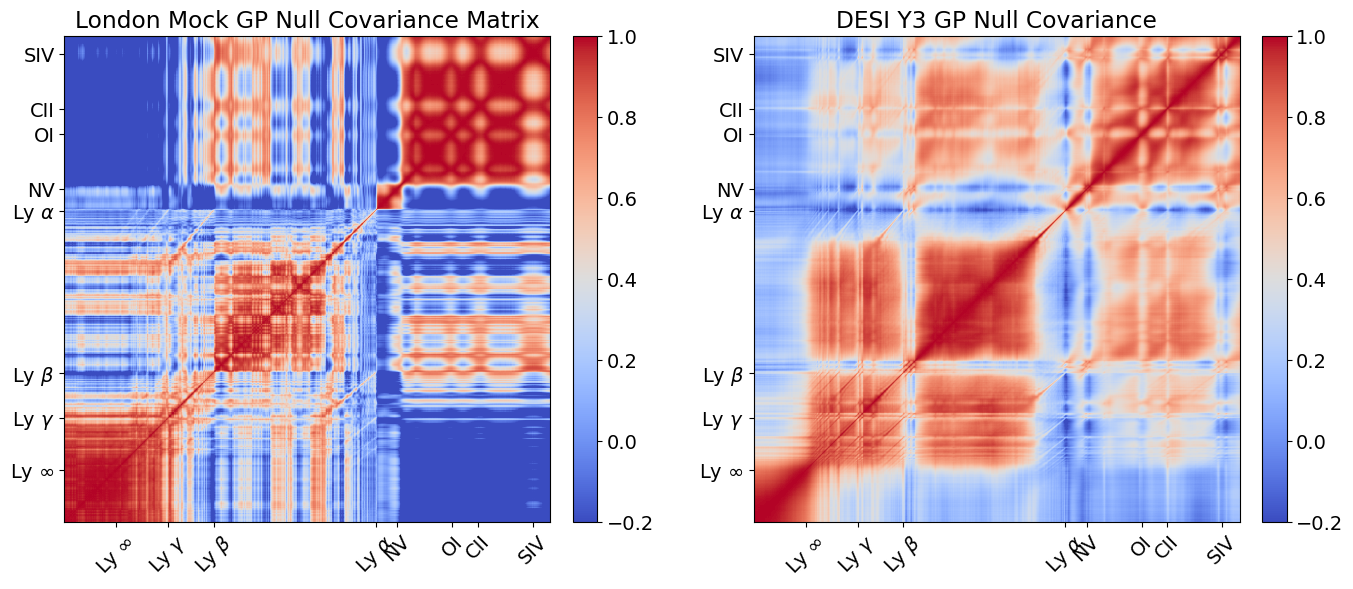

In [6]:
plot_covariance_matrices(london_model, loa_model, lyman_limit, lya_wavelength, lyb_wavelength, lyg_wavelength, nv_wavelength, oi_wavelength, cii_wavelength, siv_wavelength, title1="London Mock GP Null Covariance Matrix", title2="DESI Y3 GP Null Covariance", save_path="covariance_matrix_comparison_london_loa.png")

In [7]:
qso_model.rest_wavelengths.min(), qso_model.rest_wavelengths.max()

(850.75, 1420.75)

In [8]:
model_saved = torch.load("../data/loa/learnlogs/model_checkpoint_epoch_90.pt", map_location=torch.device('cpu') )

## Slides